In [1]:
import pandas as pd
from helpers import *
import os

from sklearn.model_selection import train_test_split

In [2]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = pd.read_excel("streeteasy_features_log_labeled.xlsx")
df = my_qtcheck.set_type(origin, as_category=["bed_bath_constraint", "building_era", "cluster_name", "amenity_level"])

<class 'pandas.DataFrame'>
RangeIndex: 3512 entries, 0 to 3511
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   size_sqft            3512 non-null   float64 
 1   min_to_subway        3512 non-null   float64 
 2   building_era         3512 non-null   category
 3   relative_floor       3512 non-null   float64 
 4   relative_size        3512 non-null   float64 
 5   bed_bath_constraint  3512 non-null   category
 6   cluster_name         3512 non-null   category
 7   amenity_level        3512 non-null   category
 8   rent                 3512 non-null   float64 
dtypes: category(4), float64(5)
memory usage: 151.1 KB


In [3]:
# 독립변수 분리
feature = df.drop(columns=["rent"])

# 종속변수 분리
target = df["rent"]

# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((2809, 8), (703, 8), (2809,), (703,))

### 저장폴더 구성

In [4]:
# 튜닝 완료된 모델이 저장되어있는 폴더
project_name = "streeteasy"
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

# feature importance 기반 재학습된 모델이 저장될 폴더
work_dir = f"{project_name}/importance"

if not os.path.exists(work_dir):
    os.makedirs(work_dir)

### 임계값 정하기

In [5]:
cum_ratio = 0.95

if not 0.0 < cum_ratio <= 1.0:    # (0, 1] 범위를 벗어난 경우
        raise ValueError(f"cum_ratio 는 (0.0, 1.0] 범위여야 합니다: {cum_ratio}")

### 6. 하이퍼파라미터 튜닝 후 최고 성능 모델 로드 및 성능 확인

In [6]:
estimator = my_ml.load_model(f"{tuned_dir}/xgb_tuned.pkl")
my_ml.reg_score(estimator, x_test, y_test)

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
XGBRegressor,0.854478,0.1464,0.038061,0.195091,0.020485,0.017333,-0.001193


### 7. XGBRegressor 모델에 대한 Feature Importance

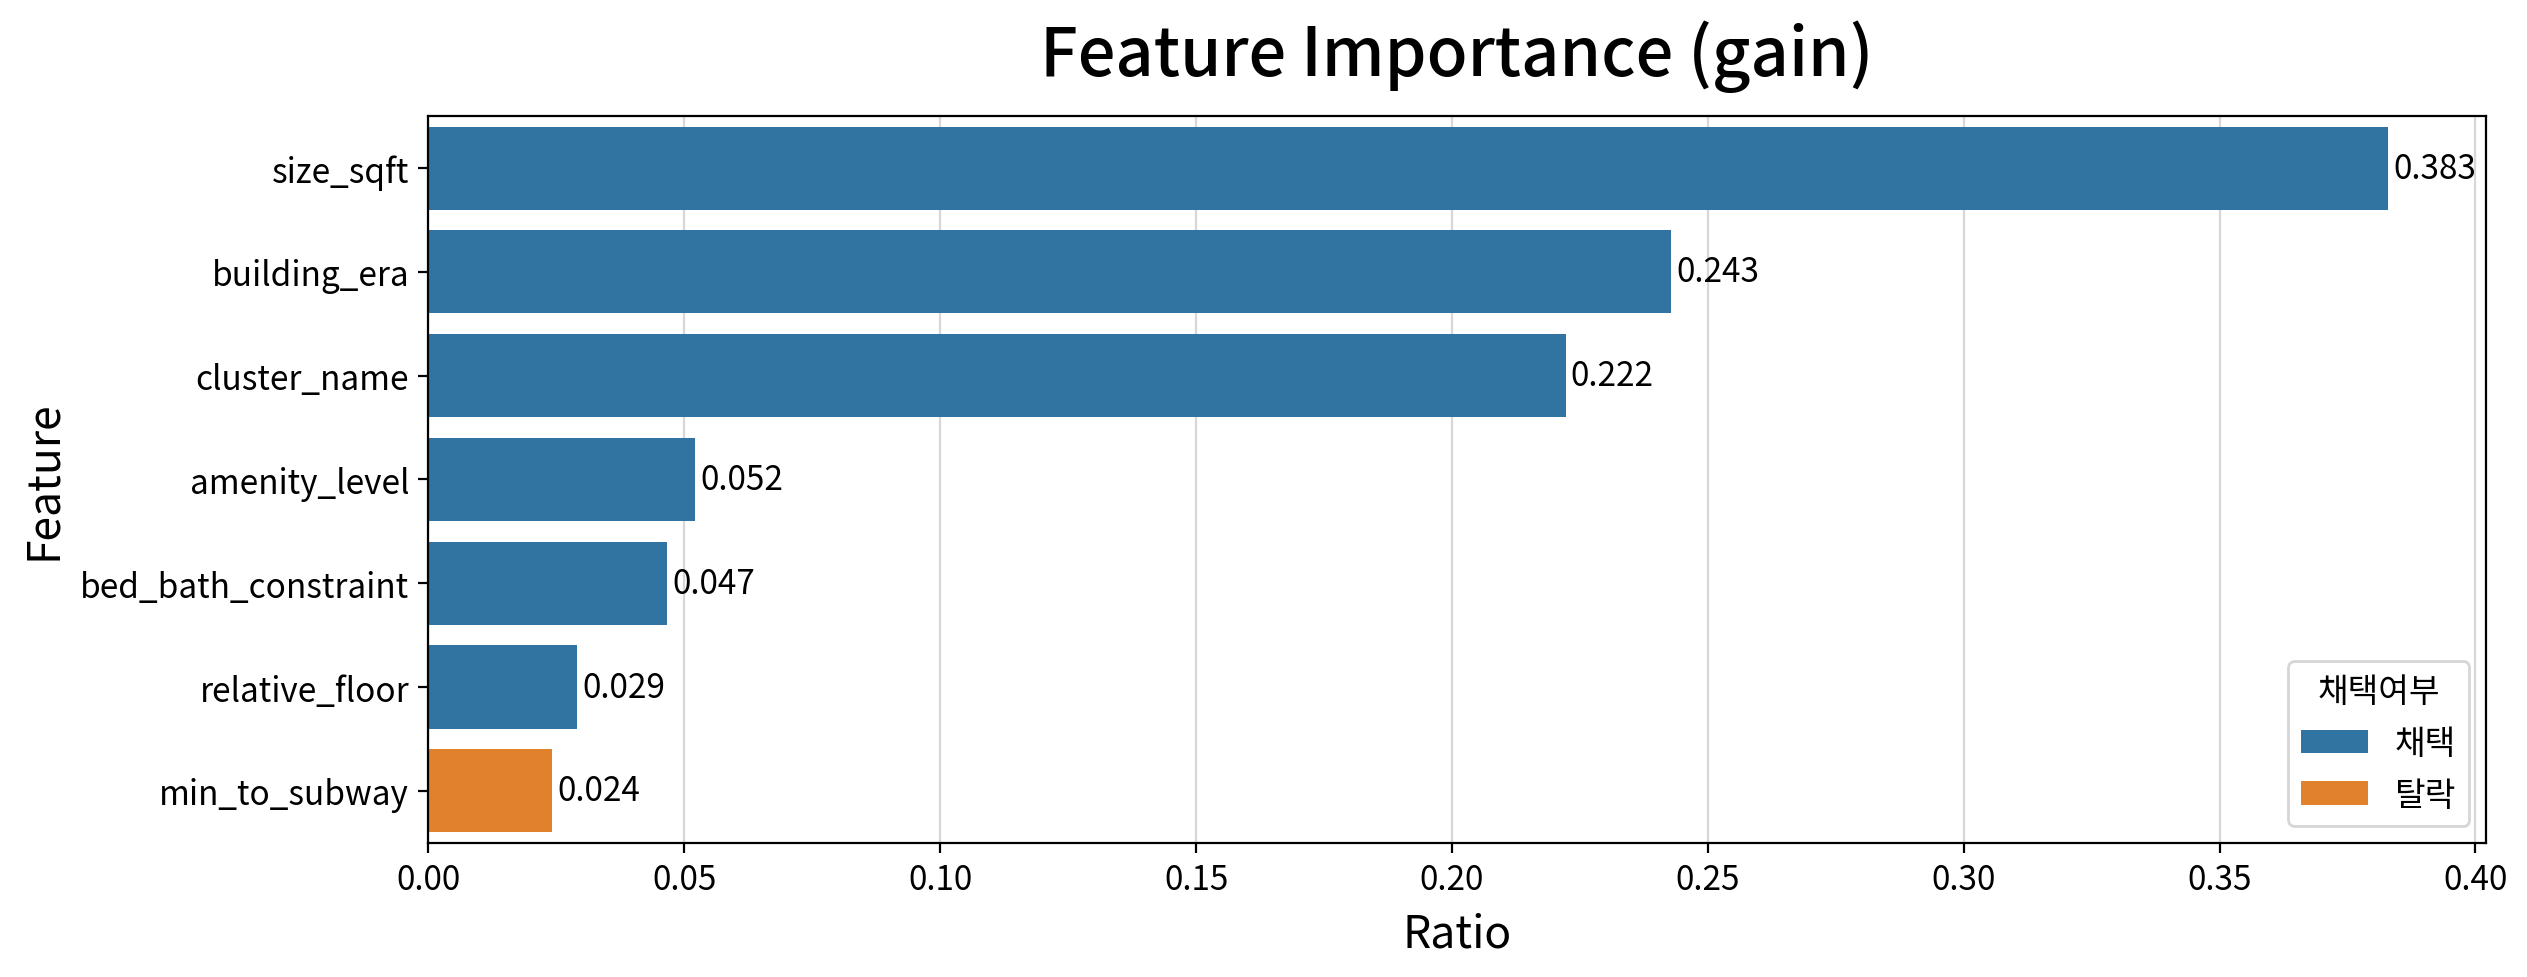

,Importance,Ratio,CumRatio,채택여부
Feature,,,,
size_sqft,1.306985,0.382898,0.382898,채택
building_era,0.828709,0.242781,0.625679,채택
cluster_name,0.758521,0.222218,0.847897,채택
amenity_level,0.177904,0.052119,0.900016,채택
bed_bath_constraint,0.159217,0.046645,0.946661,채택
relative_floor,0.099396,0.029119,0.975780,채택
min_to_subway,0.082671,0.024220,1.000000,탈락


In [7]:
fi = my_diag.feature_importance(estimator, cum_ratio=0.95)
fi

In [8]:
feature_names = fi[fi['채택여부'] == '채택'].index.tolist()
feature_names

['size_sqft',
 'building_era',
 'cluster_name',
 'amenity_level',
 'bed_bath_constraint',
 'relative_floor']

In [9]:
x_train_imp = x_train[feature_names]
x_test_imp = x_test[feature_names]

print("원본 훈련 데이터셋 변수 개수:", x_train.shape[1])
print("원본 검증 데이터셋 변수 개수:", x_test.shape[1])
print("채택된 변수만 남긴 훈련 데이터셋 변수 개수:", x_train_imp.shape[1])
print("채택된 변수만 남긴 검증 데이터셋 변수 개수:", x_test_imp.shape[1])

원본 훈련 데이터셋 변수 개수: 8
원본 검증 데이터셋 변수 개수: 8
채택된 변수만 남긴 훈련 데이터셋 변수 개수: 6
채택된 변수만 남긴 검증 데이터셋 변수 개수: 6


In [14]:
from xgboost import XGBRegressor

# XGBoost 기본모델
model = XGBRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_name = (
    model.__class__.__name__
    .lower()
    .removesuffix('regressor')
)

model_imp = my_ml.fit_pipeline(
    model=model,
    x_train=x_train_imp,
    y_train=y_train,
    vif=True,
    scale=False,
    encode=True,
    name=model_name,
    save_path=f"{work_dir}/{model_name}_imp.pkl",
    verbose=True
)

model_imp

대상: 2809행 x 6열 | 모델: xgb
명목형: ['building_era', 'cluster_name', 'amenity_level', 'bed_bath_constraint']
연속형: ['size_sqft', 'relative_floor']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: 더미변수 인코딩(drop_first=False)

모델 학습 완료: xgb
모델 저장: streeteasy/importance/xgb_imp.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['size_sqft','building_era','cluster_name','amenity_level', 'bed_bath_constraint','relative_floor']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
name_,str,'xgb'
pipeline_info_,dict,"{'ca...te': 'mo...nt', 'co...ls': ['si...ft', 're...or'], 'dr...st': False, 'encode': True, ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [11]:
models = {"xgb_imp": model_imp}

my_ml.reg_tunes("streeteasy", models, x_train=x_train_imp, y_train=y_train,
                x_test=x_test_imp, y_test=y_test, practice=False, plot=False,
                workdir="importance")

작업 폴더: streeteasy\importance
탐색 범위: 실무용
탐색 완료 [ 1/ 1] : xgb_imp (22.2초, CV RMSE=0.2043)
    최적 조합: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 1000}

모델 1개 튜닝·저장 완료 → streeteasy\importance


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap,Score
name,,,,,,,,,,,,
xgb_imp_tuned,1,Contender,XGBRegressor,0.84255,0.151998,0.04118,0.202929,0.021298,0.01796,-0.001155,0.0,4.927826


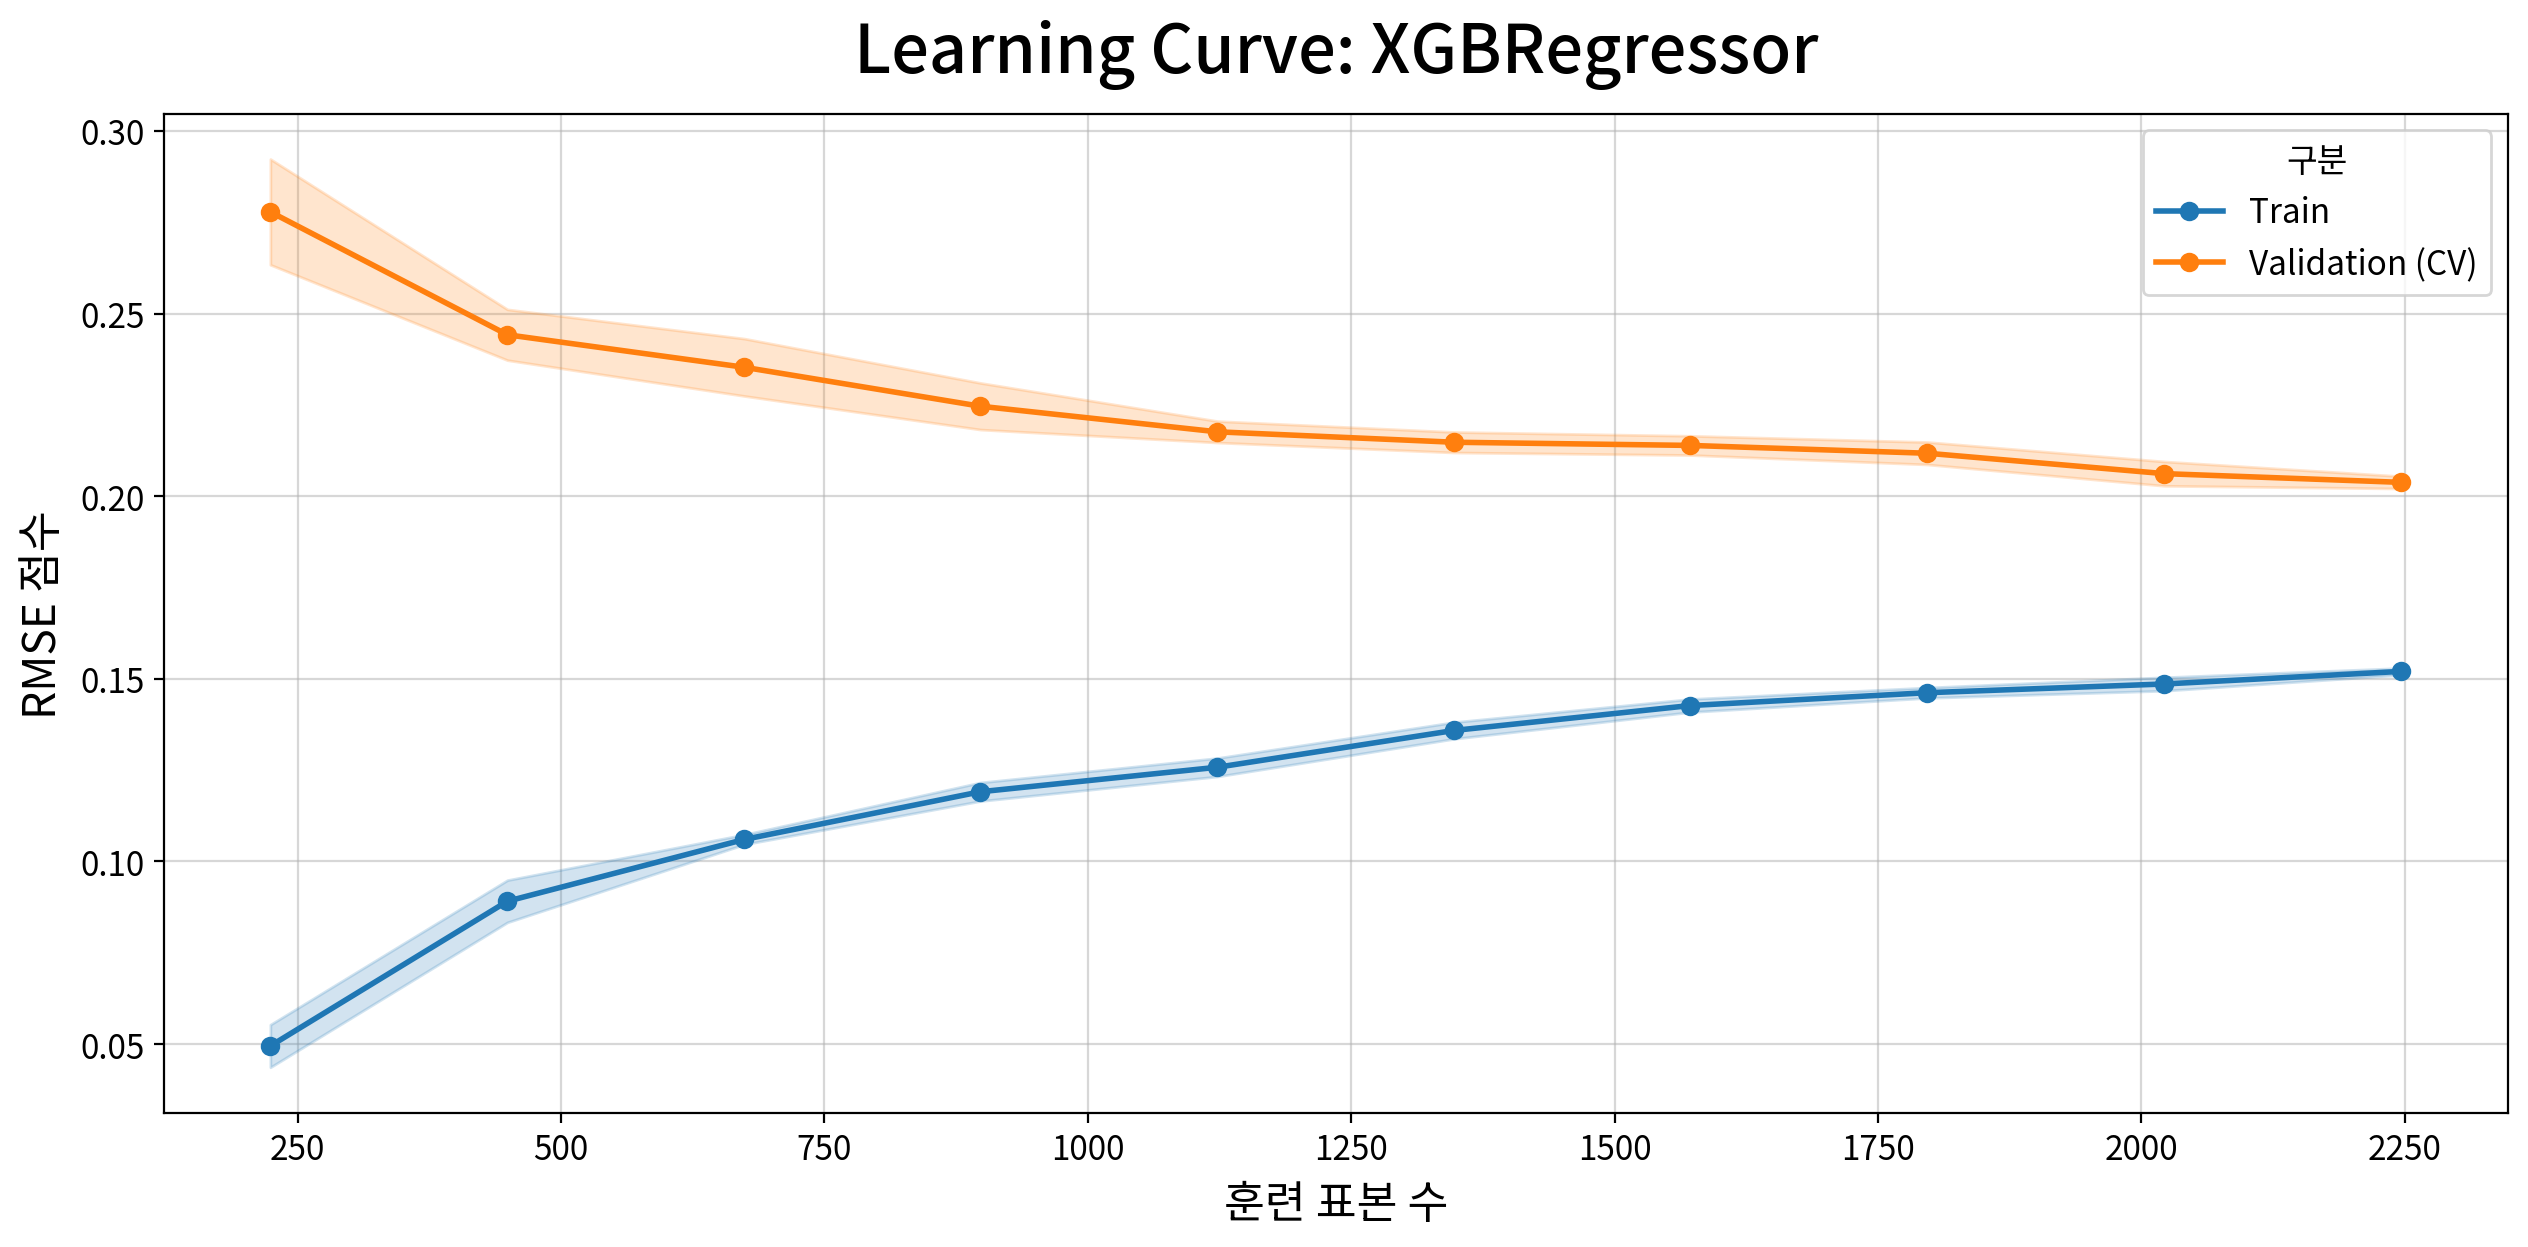

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.157546,0.204270,0.002354,0.202929,0.046724,22.87,과대적합
MAE,0.118822,0.152201,0.002755,0.151998,0.033380,21.93,과대적합
R2,0.902017,0.834921,0.009151,0.842550,0.067095,6.71,일반화



◆ Fit Diagnosis: XGBRegressor  (threshold=20%, 기준=Train↔CV 5-Fold)
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - RMSE    Train=     0.1575  CV=     0.2043 (±0.0024)  Test=     0.2029  Gap%=   22.87%  [과대적합] [주의]
  - MAE     Train=     0.1188  CV=     0.1522 (±0.0028)  Test=     0.1520  Gap%=   21.93%  [과대적합] [주의]
  - R2      Train=     0.9020  CV=     0.8349 (±0.0092)  Test=     0.8426  Gap%=    6.71%  [일반화] [정상]

  ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) - 훈련↔CV 격차가 큼
      · train R2=0.9020 (과소적합 기준 < 0.05) · CV R2=0.8349



In [12]:
tune_model = my_ml.load_model(f"{work_dir}/xgb_imp_tuned.pkl")
my_diag.overfit(tune_model, x_train=x_train_imp, y_train=y_train, x_test=x_test_imp, y_test=y_test)